In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def load_data():
    # Change file path depending on the location of the data
    path = "/content/drive/MyDrive/warehouse-bottleneck-analyzer/data/raw/warehouse_line_throughput_synthetic.csv"
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    df = df.set_index("timestamp")
    return df

df = load_data()

In [4]:
print(df.shape)
print(df.head())
print(df.info())
print(df.describe().T)
print(df.isna().sum().sort_values(ascending=False))
print(df["bottleneck_flag"].value_counts(normalize=True))
print(df["next_hour_backlog_risk"].value_counts(normalize=True))

(2159, 32)
                           date  hour       line_id  total_stations  shift  \
timestamp                                                                    
2026-04-01 00:00:00  2026-04-01     0  PACK-LINE-01              20  night   
2026-04-01 01:00:00  2026-04-01     1  PACK-LINE-01              20  night   
2026-04-01 02:00:00  2026-04-01     2  PACK-LINE-01              20  night   
2026-04-01 03:00:00  2026-04-01     3  PACK-LINE-01              20  night   
2026-04-01 04:00:00  2026-04-01     4  PACK-LINE-01              20  night   

                       weekday  planned_work  stations_down  \
timestamp                                                     
2026-04-01 00:00:00  Wednesday           893              2   
2026-04-01 01:00:00  Wednesday           736              0   
2026-04-01 02:00:00  Wednesday           696              0   
2026-04-01 03:00:00  Wednesday           783              2   
2026-04-01 04:00:00  Wednesday           723              2   



In [5]:
df[[
    "planned_work",
    "line_capacity",
    "units_packed",
    "backlog_units"
]].head(10)

,planned_work,line_capacity,units_packed,backlog_units
timestamp,,,,
2026-04-01 00:00:00,893,820,789,104.0
2026-04-01 01:00:00,736,910,878,0.0
2026-04-01 02:00:00,696,640,675,21.0
2026-04-01 03:00:00,783,672,681,123.0
2026-04-01 04:00:00,723,539,522,324.0
2026-04-01 05:00:00,898,704,630,592.0
2026-04-01 06:00:00,1366,1540,1634,324.0
2026-04-01 07:00:00,1149,1530,1567,0.0
2026-04-01 08:00:00,1409,1280,1308,101.0


In [6]:
pd.crosstab(df["bottleneck_flag"], df["next_hour_backlog_risk"], normalize="index")

next_hour_backlog_risk,0,1
bottleneck_flag,,
0,0.986702,0.013298
1,0.795850,0.204150


['total_stations', 'scaled_back_work']


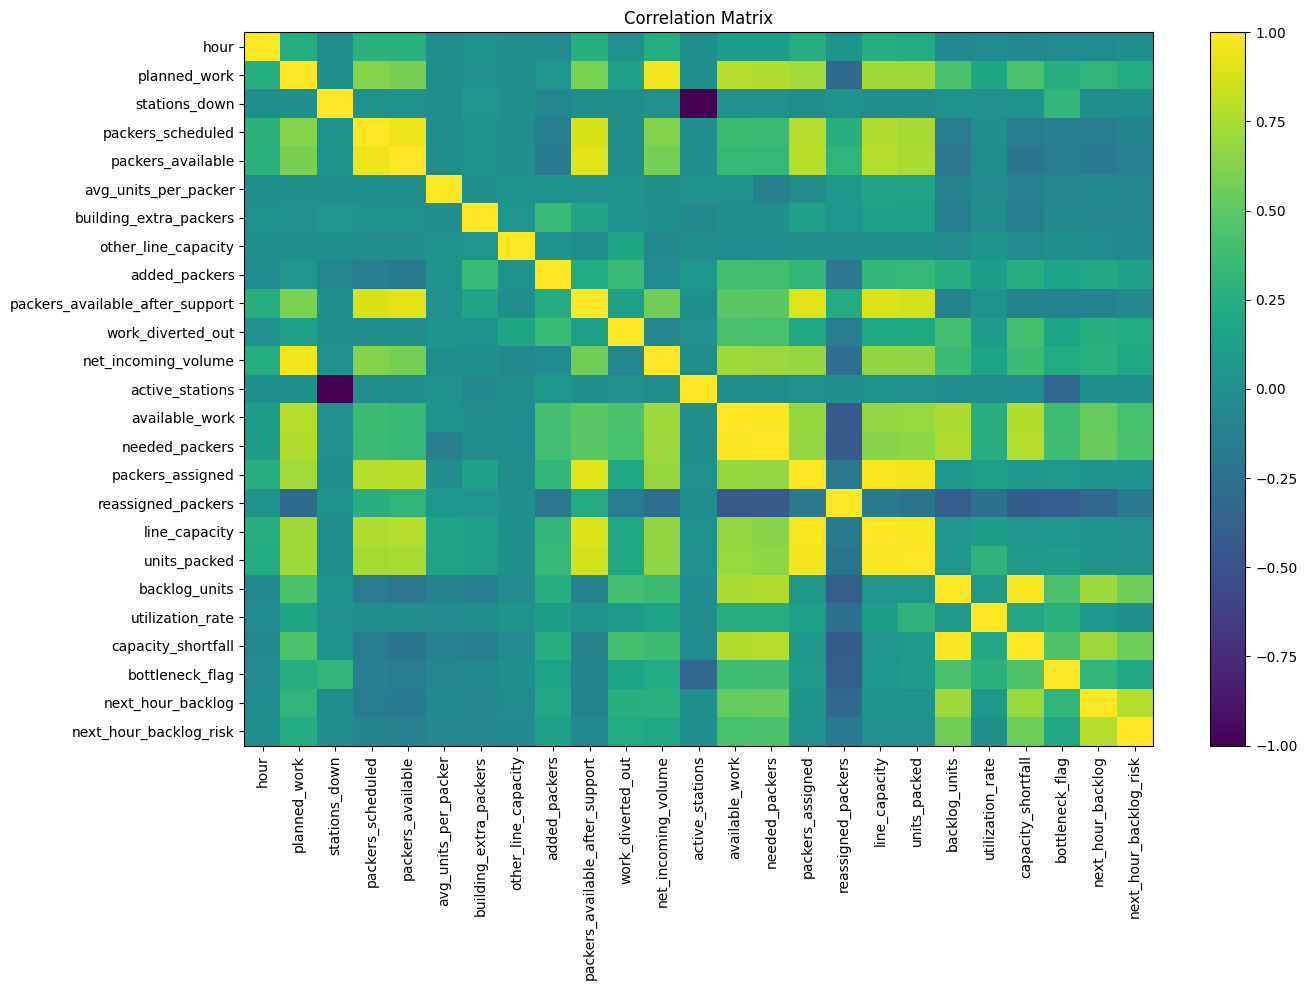

In [7]:
constant_cols = [
    col for col in df.select_dtypes(include="number").columns
    if df[col].nunique() <= 1
]

print(constant_cols)

df_corr = df.drop(columns=constant_cols)

numeric_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns

corr = df_corr[numeric_cols].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [8]:
target_corr = (
    corr["next_hour_backlog_risk"]
    .sort_values(ascending=False)
)

print(target_corr)

next_hour_backlog_risk             1.000000
next_hour_backlog                  0.775104
backlog_units                      0.568682
capacity_shortfall                 0.556654
needed_packers                     0.422113
available_work                     0.414368
planned_work                       0.233830
work_diverted_out                  0.224209
net_incoming_volume                0.198950
bottleneck_flag                    0.192277
added_packers                      0.147323
packers_assigned                   0.023100
line_capacity                      0.010730
units_packed                       0.008562
utilization_rate                   0.006959
active_stations                    0.002168
hour                               0.002039
stations_down                     -0.002168
other_line_capacity               -0.044421
packers_available_after_support   -0.052644
building_extra_packers            -0.055886
avg_units_per_packer              -0.056314
packers_scheduled               

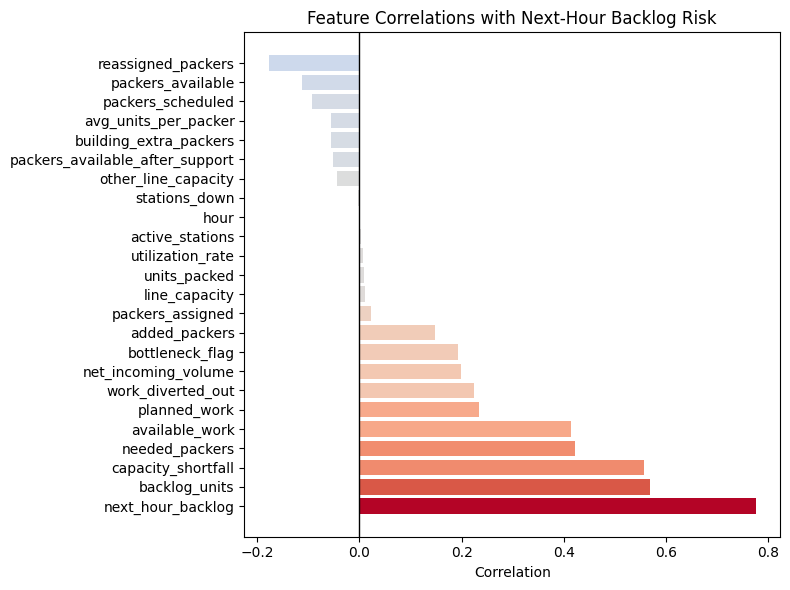

In [9]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Normalize values from -1 to 1
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Choose colormap
cmap = cm.coolwarm

# Generate colors from correlation values
colors = cmap(norm(target_corr.values))

# Plot
plot_corr = target_corr.drop("next_hour_backlog_risk")

# Plot
plt.figure(figsize=(8, 6))

plt.barh(
    plot_corr.index,
    plot_corr.values,
    color=colors
)

# Vertical zero line
plt.axvline(0, color="black", linewidth=1)

plt.title("Feature Correlations with Next-Hour Backlog Risk")
plt.xlabel("Correlation")

plt.tight_layout()
plt.show()

In [10]:
summary_cols = [
    "planned_work",
    "net_incoming_volume",
    "line_capacity",
    "units_packed",
    "backlog_units",
    "capacity_shortfall",
    "utilization_rate",
    "packers_assigned",
    "reassigned_packers",
    "stations_down",
    "work_diverted_out",
    "scaled_back_work"
]

df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
planned_work,2159.0,1123.605373,327.193152,389.000,864.500,1105.000,1411.000,1600.000
net_incoming_volume,2159.0,1109.578740,333.215509,372.000,847.000,1091.000,1381.000,2000.000
line_capacity,2159.0,1125.403891,307.621233,460.000,850.000,1170.000,1360.000,1960.000
units_packed,2159.0,1114.781843,317.605718,386.000,840.500,1149.000,1355.000,1942.000
backlog_units,2159.0,355.781496,341.898902,0.000,45.500,277.000,580.625,1910.000
capacity_shortfall,2159.0,350.475336,343.847773,0.000,0.000,282.250,579.125,1870.000
utilization_rate,2159.0,0.988764,0.054119,0.777,0.953,0.989,1.026,1.165
packers_assigned,2159.0,13.311255,3.577478,5.000,10.000,14.000,16.000,20.000
reassigned_packers,2159.0,0.647985,1.534960,0.000,0.000,0.000,0.000,9.000
stations_down,2159.0,1.250579,1.398635,0.000,0.000,1.000,2.000,4.000


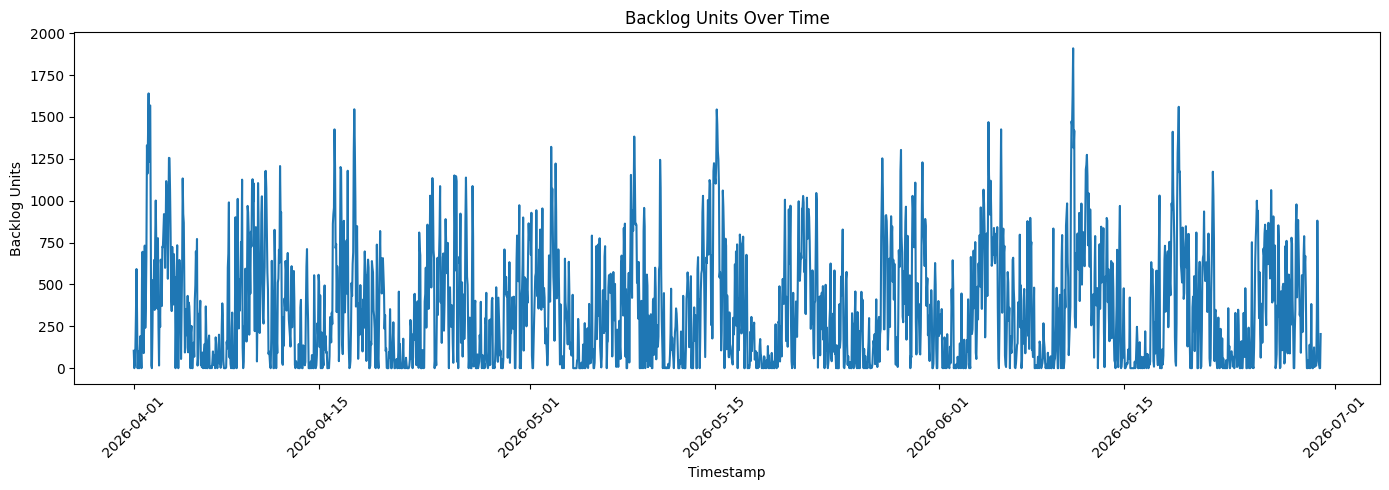

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["backlog_units"])
plt.title("Backlog Units Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Backlog Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

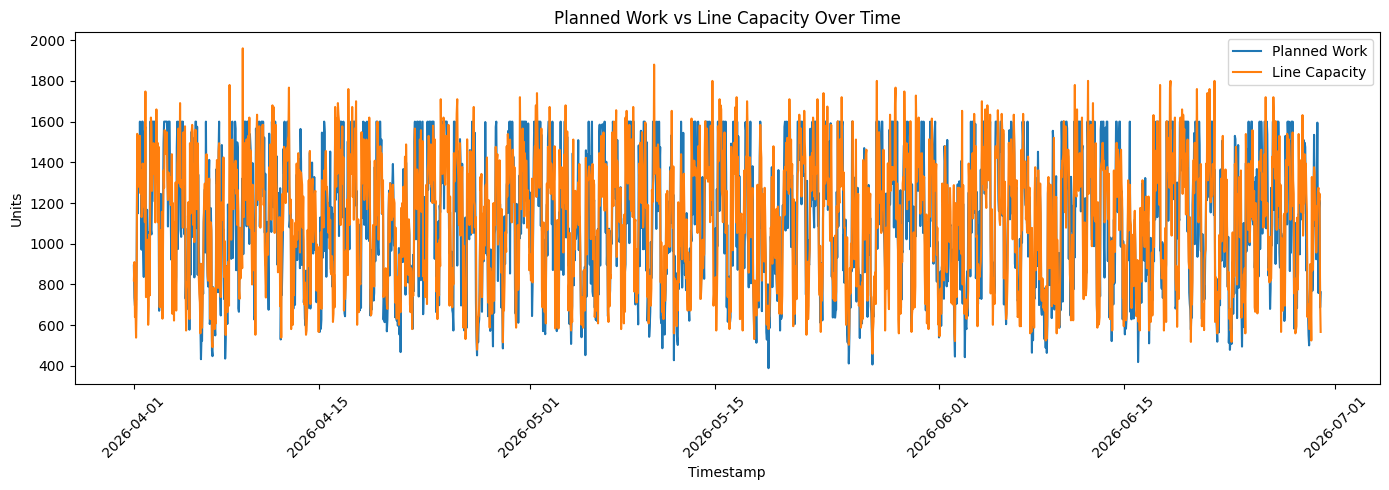

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["planned_work"], label="Planned Work")
plt.plot(df.index, df["line_capacity"], label="Line Capacity")
plt.title("Planned Work vs Line Capacity Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

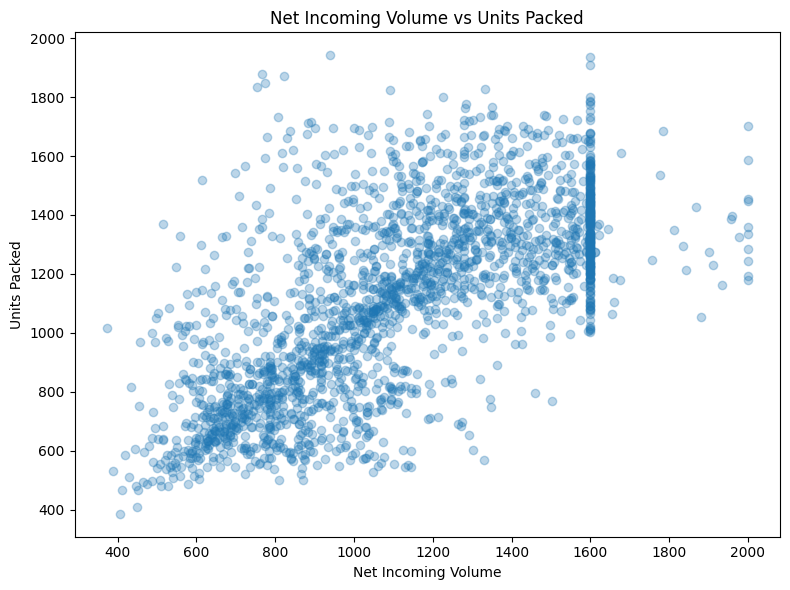

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df["net_incoming_volume"], df["units_packed"], alpha=0.3)
plt.title("Net Incoming Volume vs Units Packed")
plt.xlabel("Net Incoming Volume")
plt.ylabel("Units Packed")
plt.tight_layout()
plt.show()

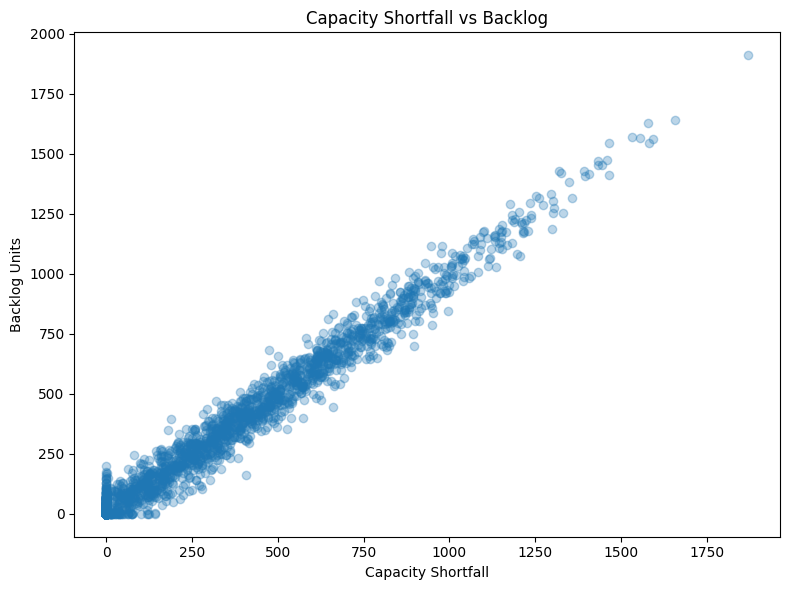

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df["capacity_shortfall"], df["backlog_units"], alpha=0.3)
plt.title("Capacity Shortfall vs Backlog")
plt.xlabel("Capacity Shortfall")
plt.ylabel("Backlog Units")
plt.tight_layout()
plt.show()

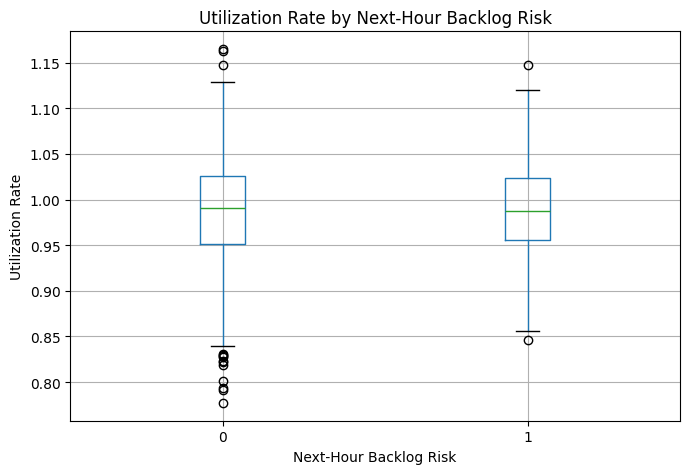

In [15]:
df.boxplot(
    column="utilization_rate",
    by="next_hour_backlog_risk",
    figsize=(7, 5)
)

plt.title("Utilization Rate by Next-Hour Backlog Risk")
plt.suptitle("")
plt.xlabel("Next-Hour Backlog Risk")
plt.ylabel("Utilization Rate")
plt.tight_layout()
plt.show()

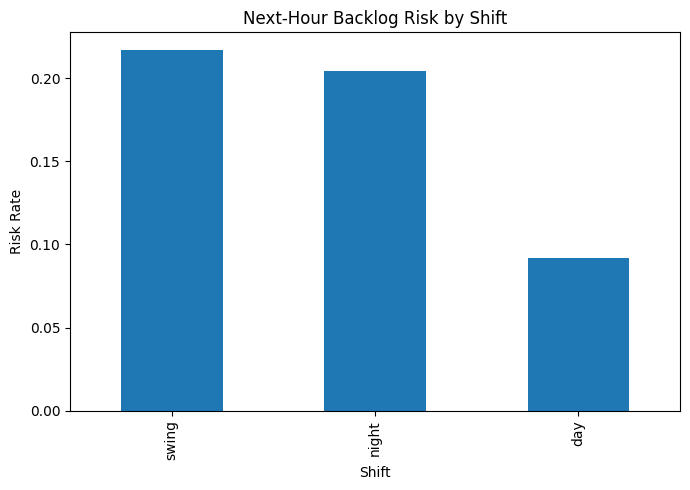

In [16]:
risk_by_shift = (
    df.groupby("shift")["next_hour_backlog_risk"]
    .mean()
    .sort_values(ascending=False)
)

risk_by_shift.plot(kind="bar", figsize=(7, 5))
plt.title("Next-Hour Backlog Risk by Shift")
plt.xlabel("Shift")
plt.ylabel("Risk Rate")
plt.tight_layout()
plt.show()

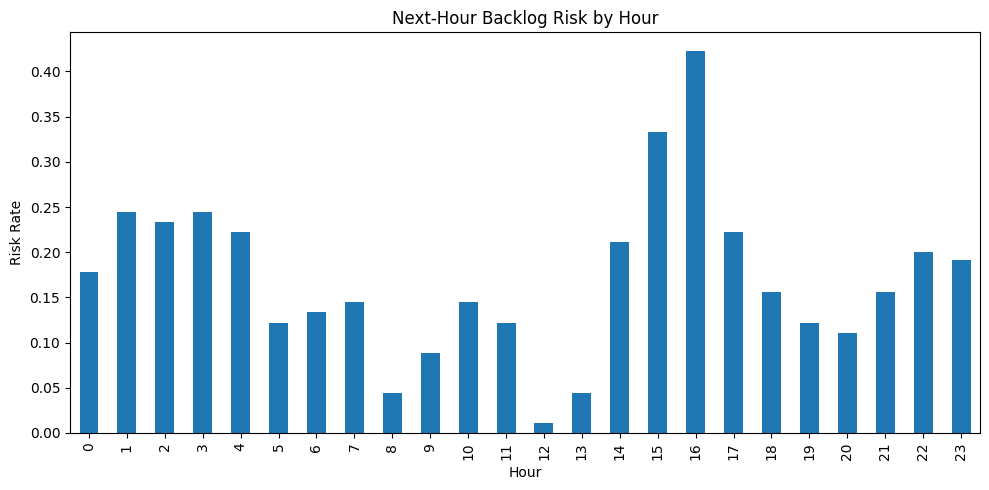

In [17]:
risk_by_hour = df.groupby("hour")["next_hour_backlog_risk"].mean()

risk_by_hour.plot(kind="bar", figsize=(10, 5))
plt.title("Next-Hour Backlog Risk by Hour")
plt.xlabel("Hour")
plt.ylabel("Risk Rate")
plt.tight_layout()
plt.show()

In [18]:
risk_comparison = (
    df.groupby("next_hour_backlog_risk")[summary_cols]
    .mean()
    .T
)

risk_comparison["difference"] = risk_comparison[1] - risk_comparison[0]

risk_comparison.sort_values("difference", ascending=False)

next_hour_backlog_risk,0,1,difference
backlog_units,267.523603,783.915989,516.392386
capacity_shortfall,263.591760,771.943089,508.351330
planned_work,1088.876536,1292.073171,203.196634
net_incoming_volume,1079.486453,1255.554878,176.068426
work_diverted_out,20.675978,62.712737,42.036759
line_capacity,1123.905587,1132.672087,8.766500
units_packed,1113.547486,1120.769648,7.222162
packers_assigned,13.273743,13.493225,0.219482
utilization_rate,0.988593,0.989593,0.001000
scaled_back_work,0.000000,0.000000,0.000000


In [19]:
print(df["intervention_type"].value_counts())

intervention_summary = (
    df.groupby("intervention_type")[[
        "planned_work",
        "net_incoming_volume",
        "line_capacity",
        "units_packed",
        "backlog_units",
        "next_hour_backlog_risk"
    ]]
    .mean()
    .sort_values("next_hour_backlog_risk", ascending=False)
)

intervention_summary

intervention_type
none                               1432
added_packers                       359
added_packers_and_work_diverted     287
work_diverted                        81
Name: count, dtype: int64


,planned_work,net_incoming_volume,line_capacity,units_packed,backlog_units,next_hour_backlog_risk
intervention_type,,,,,,
work_diverted,1234.481481,1076.333333,1126.074074,1130.827160,845.737654,0.543210
added_packers_and_work_diverted,1183.536585,1038.268293,1285.296167,1290.132404,698.697735,0.372822
added_packers,1166.378830,1181.056407,1279.958217,1275.384401,454.254178,0.220056
none,1094.599162,1107.831878,1054.574022,1038.467877,234.653631,0.097067


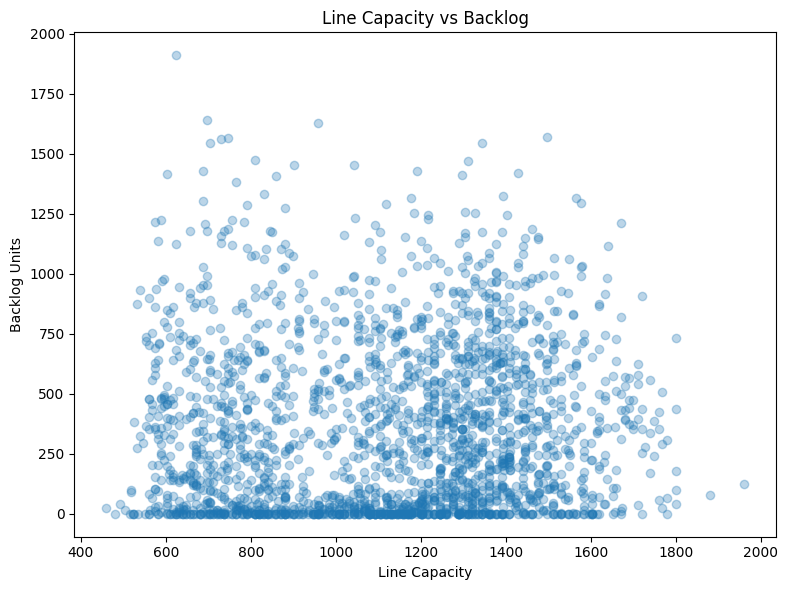

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df["line_capacity"], df["backlog_units"], alpha=0.3)
plt.title("Line Capacity vs Backlog")
plt.xlabel("Line Capacity")
plt.ylabel("Backlog Units")
plt.tight_layout()
plt.show()

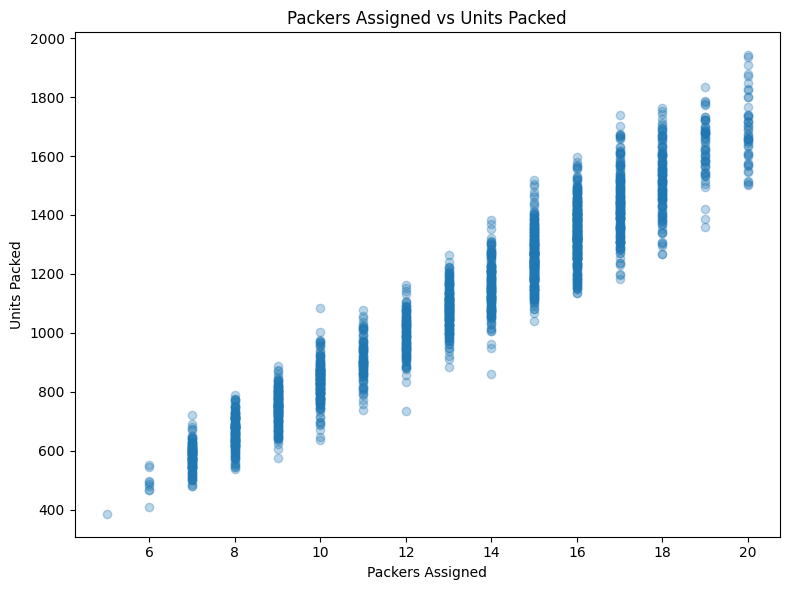

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(df["packers_assigned"], df["units_packed"], alpha=0.3)
plt.title("Packers Assigned vs Units Packed")
plt.xlabel("Packers Assigned")
plt.ylabel("Units Packed")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [23]:
target = "next_hour_backlog_risk"

df = df.sort_values("timestamp").reset_index(drop=True)

df["capacity_gap"] = df["available_work"] - df["line_capacity"]

df["work_pressure"] = df["available_work"] / (df["line_capacity"] + 1)

df["backlog_planned_ratio"] = df["backlog_units"] / (df["planned_work"] + 1)

df["backlog_lag_1"] = df["backlog_units"].shift(1)
df["backlog_lag_2"] = df["backlog_units"].shift(2)

df["capacity_gap_lag_1"] = df["capacity_gap"].shift(1)

df["backlog_change"] = df["backlog_units"].diff()

df = df.dropna().reset_index(drop=True)

In [24]:
top_features = [
    "backlog_units",
    "available_work",
    "capacity_gap",
    "work_pressure",
    "bottleneck_flag"
]

expanded_features = [
    "backlog_units",
    "available_work",
    "capacity_gap",
    "work_pressure",
    "backlog_planned_ratio",
    "line_capacity",
    "units_packed",
    "utilization_rate",
    "packers_assigned",
    "reassigned_packers",
    "work_diverted_out",
    "bottleneck_flag"
]

full_features = [
    "hour",
    "stations_down",
    "active_stations",
    "packers_scheduled",
    "packers_available",
    "packers_available_after_support",
    "added_packers",
    "packers_assigned",
    "reassigned_packers",
    "avg_units_per_packer",
    "planned_work",
    "work_diverted_out",
    "net_incoming_volume",
    "line_capacity",
    "units_packed",
    "available_work",
    "backlog_units",
    "capacity_shortfall",
    "utilization_rate",
    "bottleneck_flag",
    "capacity_gap",
    "work_pressure",
    "backlog_planned_ratio",
    "backlog_lag_1",
    "backlog_lag_2",
    "capacity_gap_lag_1",
    "backlog_change"
]

In [25]:
def chronological_split(df, features, target, train_size=0.75):
    split_idx = int(len(df) * train_size)

    X_train = df.loc[:split_idx - 1, features]
    y_train = df.loc[:split_idx - 1, target]

    X_test = df.loc[split_idx:, features]
    y_test = df.loc[split_idx:, target]

    return X_train, X_test, y_train, y_test

In [26]:
import numpy as np

def evaluate_model(model, X_test, y_test, model_name, feature_set_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results = {
        "model": model_name,
        "feature_set": feature_set_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }

    print(f"\n{model_name} — {feature_set_name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

    return results

In [27]:
feature_sets = {
    "Top Features": top_features,
    "Expanded Features": expanded_features,
    "Full Features": full_features
}

all_results = []

for feature_set_name, features in feature_sets.items():

    X_train, X_test, y_train, y_test = chronological_split(
        df=df,
        features=features,
        target=target,
        train_size=0.75
    )

    # Logistic Regression pipeline
    log_reg = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    log_reg.fit(X_train, y_train)

    all_results.append(
        evaluate_model(
            log_reg,
            X_test,
            y_test,
            model_name="Logistic Regression",
            feature_set_name=feature_set_name
        )
    )

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)

    all_results.append(
        evaluate_model(
            rf,
            X_test,
            y_test,
            model_name="Random Forest",
            feature_set_name=feature_set_name
        )
    )


Logistic Regression — Top Features
[[343  94]
 [ 23  80]]
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       437
           1       0.46      0.78      0.58       103

    accuracy                           0.78       540
   macro avg       0.70      0.78      0.72       540
weighted avg       0.85      0.78      0.80       540


Random Forest — Top Features
[[363  74]
 [ 31  72]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       437
           1       0.49      0.70      0.58       103

    accuracy                           0.81       540
   macro avg       0.71      0.76      0.73       540
weighted avg       0.84      0.81      0.82       540


Logistic Regression — Expanded Features
[[342  95]
 [ 23  80]]
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       437
           1       0.46      0.78      0.58       103

    ac

In [28]:
results_df = pd.DataFrame(all_results)

results_df.sort_values(
    by=["f1", "recall", "roc_auc"],
    ascending=False
)

,model,feature_set,accuracy,precision,recall,f1,roc_auc
1,Random Forest,Top Features,0.805556,0.493151,0.699029,0.578313,0.874364
5,Random Forest,Full Features,0.800000,0.483660,0.718447,0.578125,0.871165
0,Logistic Regression,Top Features,0.783333,0.459770,0.776699,0.577617,0.867610
2,Logistic Regression,Expanded Features,0.781481,0.457143,0.776699,0.575540,0.869254
3,Random Forest,Expanded Features,0.796296,0.477419,0.718447,0.573643,0.870898
4,Logistic Regression,Full Features,0.779630,0.454545,0.776699,0.573477,0.872165


<Axes: title={'center': 'Random Forest Feature Importance'}, ylabel='feature'>

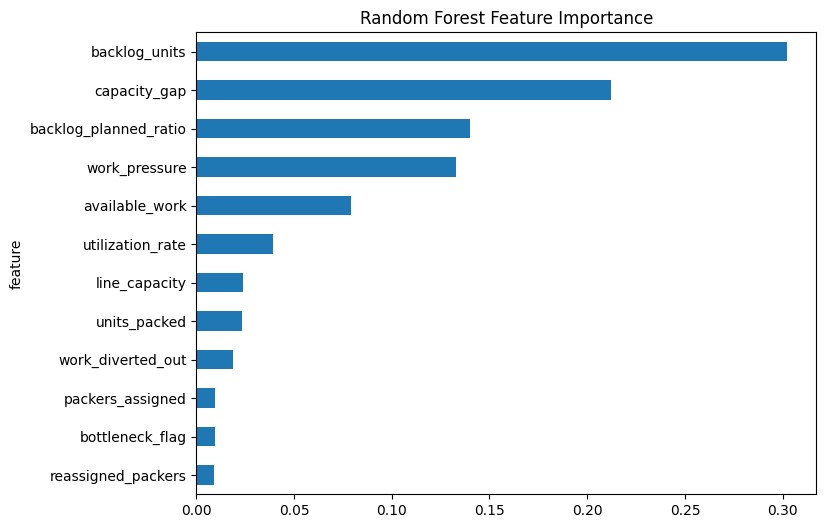

In [29]:
best_features = expanded_features

X_train, X_test, y_train, y_test = chronological_split(
    df=df,
    features=best_features,
    target=target,
    train_size=0.75
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

importance_df.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False,
    title="Random Forest Feature Importance"
)

<Axes: title={'center': 'Logistic Regression Coefficients'}, ylabel='feature'>

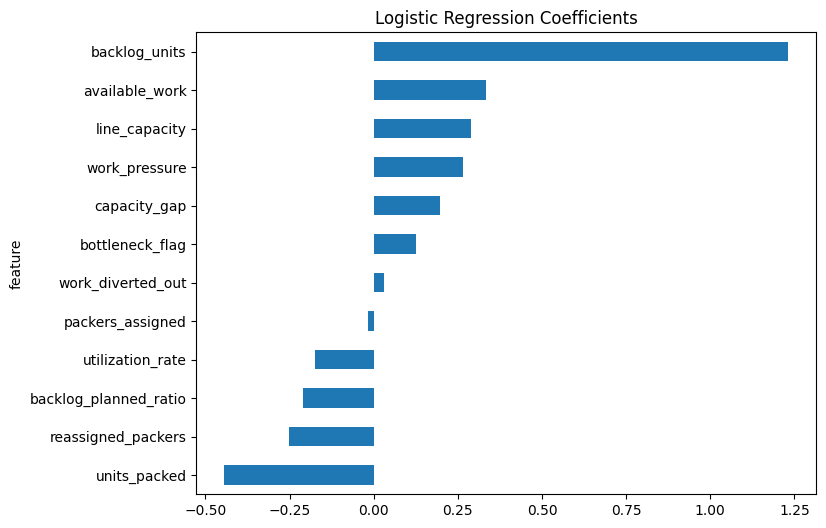

In [30]:
log_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "feature": best_features,
    "coefficient": log_reg.named_steps["model"].coef_[0]
}).sort_values("coefficient")

coef_df.plot(
    x="feature",
    y="coefficient",
    kind="barh",
    figsize=(8, 6),
    legend=False,
    title="Logistic Regression Coefficients"
)

In [31]:
from sklearn.metrics import precision_recall_curve

y_prob = rf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1]
})

threshold_df.head()

,threshold,precision,recall
0,0.002250,0.190741,1.0
1,0.002909,0.191095,1.0
2,0.003350,0.191450,1.0
3,0.003525,0.191806,1.0
4,0.003974,0.192164,1.0


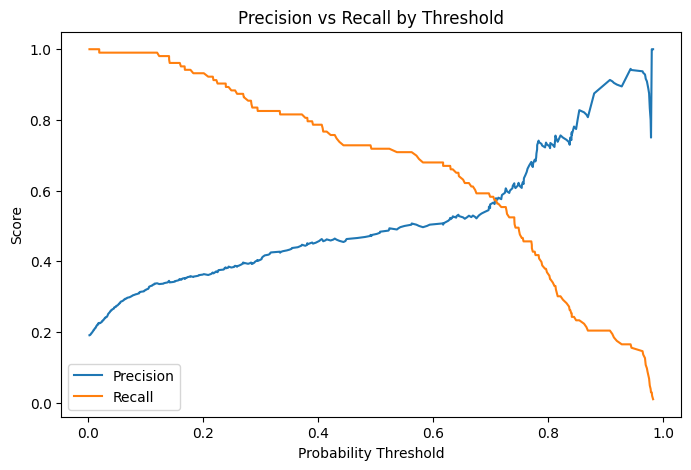

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")

plt.xlabel("Probability Threshold")
plt.ylabel("Score")

plt.title("Precision vs Recall by Threshold")

plt.legend()

plt.show()